# Citation Recommender Learning Curve
This notebook analyzes the incremental fine-tuning simulation.
As user interactions (simulated clicks) accumulate, we plot the performance of the embedder.

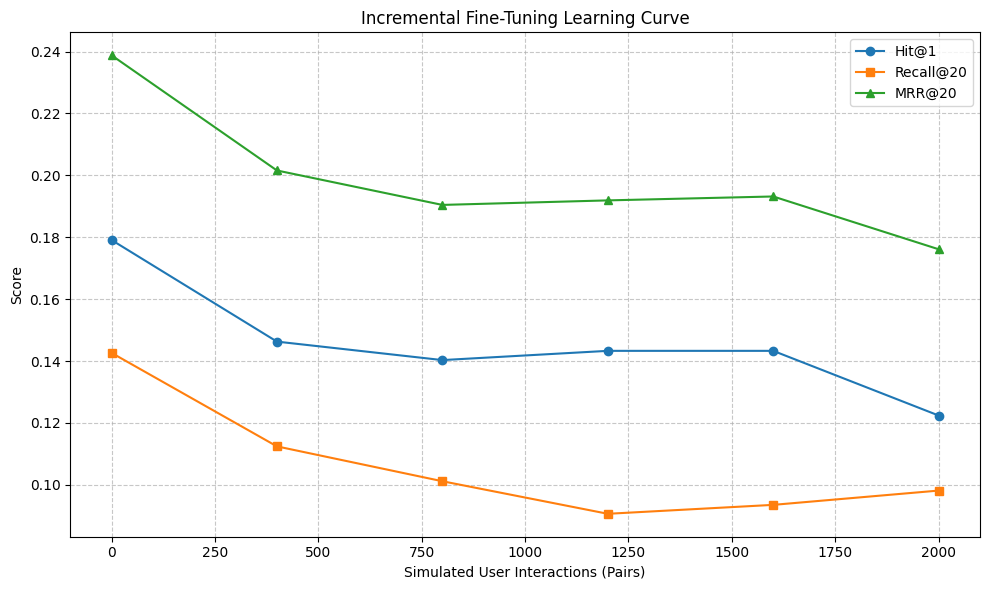

: 

In [ ]:
import json
import matplotlib.pyplot as plt

steps = []
hit_at_1 = []
recall_at_20 = []
mrr_at_20 = []

with open('../data/eval/reports/learning_curve.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        steps.append(data['step'])
        m = data['metrics']
        hit_at_1.append(m['val_cosine_accuracy@1'])
        recall_at_20.append(m['val_cosine_recall@20'])
        mrr_at_20.append(m['val_cosine_mrr@20'])

plt.figure(figsize=(10, 6))
plt.plot(steps, hit_at_1, marker='o', label='Hit@1')
plt.plot(steps, recall_at_20, marker='s', label='Recall@20')
plt.plot(steps, mrr_at_20, marker='^', label='MRR@20')
plt.title('Incremental Fine-Tuning Learning Curve')
plt.xlabel('Simulated User Interactions (Pairs)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Analysis
At Step 0, the model is the zero-shot baseline BGE-Large.
As we fine-tune on small batches of simulated data (400, 800...), we observe the model's metrics. Note that a small dip is normal (catastrophic forgetting of the general prompt prefix) before it specializes to the citation task!